# 画像分析編

## 目標
 ニューラルネットワークで画像分類を実際に体験する。また、全結合のニューラルネットワークと畳み込みを用いたニューラルネットワークの違いを理解する。第１１回は全結合のみ扱います。第１２回は畳み込みを扱います。

# 事前準備

### ライブラリのインポート

In [ ]:
import time  # このモジュールでは、時刻に関するさまざまな関数を提供します。
import random  # このモジュールでは様々な分布をもつ擬似乱数生成器を実装しています。
import matplotlib.pyplot as plt  # 可視化に関するライブラリです。
import seaborn as sn  # 可視化に関するライブラリです。
import pandas as pd
import tqdm

In [ ]:
# 機械学習ライブラリ
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchsummary import summary

### 定数の設定

In [ ]:
NUM_CLASS = 10            # 分類数
IMAGE_SIZE = (32, 32, 3)  # 画像のサイズ
BATCH_SIZE = 2000         # バッチサイズ（同時に学習するデータ数）
EPOCHS = 20               # エポック（学習回数）

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


### データセットの準備

In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
     ])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, )


classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [34:59<00:00, 81.2kB/s]


### データセットの確認

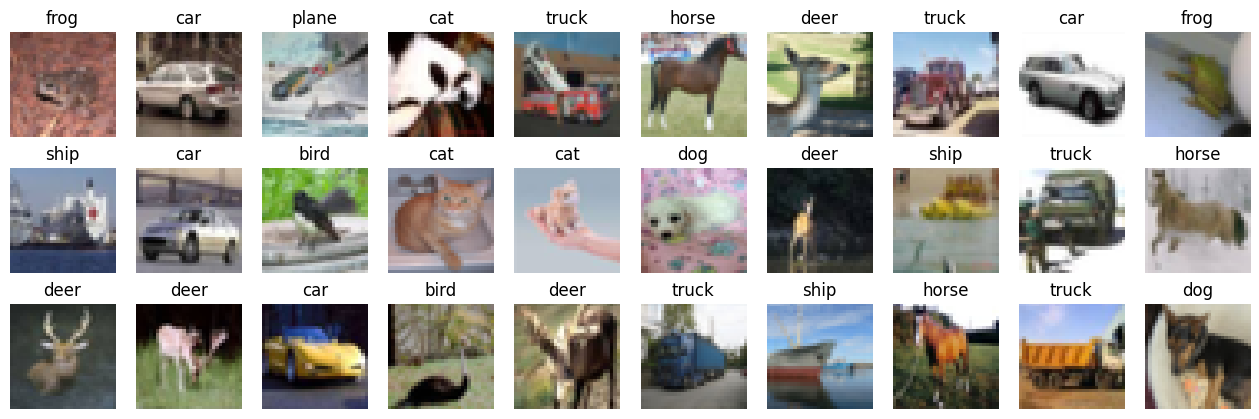

In [ ]:
# 画像の例を表示
pos = 1
#なんか型がおかしいってエラーが出たから、「/2」から「//2」にして整数に
index = random.randint(0, test_dataset.data.shape[0] // 2)
i = index

plt.figure(figsize=(16, 5))

for img in test_dataset.data[index:index + 30]:
    plt.subplot(3, 10, pos)
    plt.imshow(img)
    plt.axis('off')
    plt.title(classes[test_dataset.targets[i]])
    pos += 1
    i += 1

plt.show()

input_shape = IMAGE_SIZE[0] * IMAGE_SIZE[1] * IMAGE_SIZE[2]
output_shape = NUM_CLASS

# 課題１．画像を1次元に変換し学習

### 1-3 一次元用のモデルを設定


In [ ]:
input_shape = IMAGE_SIZE[0] * IMAGE_SIZE[1] * IMAGE_SIZE[2] # 32 * 32 * 3 = 3072
output_shape = NUM_CLASS


class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_shape, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, output_shape),
        )
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.fc(x)
        x = self.softmax(x)
        return x


model = Model()
print(model)

model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

summary(model, (input_shape,))

print('入力のサイズ：', input_shape)
print('出力のサイズ：', output_shape)

Model(
  (fc): Sequential(
    (0): Linear(in_features=3072, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=1024, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=512, bias=True)
    (7): ReLU()
    (8): Linear(in_features=512, out_features=10, bias=True)
  )
  (softmax): Softmax(dim=1)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [-1, 1024]       3,146,752
              ReLU-2                 [-1, 1024]               0
            Linear-3                 [-1, 1024]       1,049,600
              ReLU-4                 [-1, 1024]               0
            Linear-5                  [-1, 512]         524,800
              ReLU-6                  [-1, 512]               0
            Linear-7                  [-1, 512] 

上記が，課題1におけるモデルの構造です．

では，ワークシートの問3,4,5を回答してください．

### 1-4 モデルの学習

In [ ]:

def calc_loss_and_accuracy(loader_list):
    acc = 0
    cnt = 0
    loss = 0
    for (x, y) in tqdm.tqdm(loader_list, "evaluating... ", position=0, leave=True):
        x = torch.reshape(x, (-1, 3 * 32 * 32))
        x = x.to(device)
        y = y.to(device)
        pred = model(x)
        loss += criterion(pred, y).item()
        pred = torch.argmax(pred, dim=1)
        for o, t in zip(pred, y):
            if o == t:
                acc += 1
            cnt += 1
    return loss / len(loader_list), acc / cnt


In [ ]:
def train(epochs):
    train_losses, train_accs, test_losses, test_accs = [], [], [], []
    train_loader_list = list(train_loader)
    test_loader_list = list(test_loader)
    for epoch in range(epochs):
        for (x, y) in tqdm.tqdm(train_loader_list, f"[{epoch + 1}/{epochs}] training... ", position=0, leave=True):
            x = torch.reshape(x, (-1, 3 * 32 * 32))
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()

        train_loss, train_acc = calc_loss_and_accuracy(train_loader_list)
        test_loss, test_acc = calc_loss_and_accuracy(test_loader_list)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        print(
            f'\n[*] train_Loss = {train_loss} | train_Accuracy = {train_acc} | test_Loss = {test_loss}| test_Accuracy = {test_acc}')
    return train_losses, train_accs, test_losses, test_accs


st = time.time()
train_losses, train_acc, test_losses, test_acc = train(EPOCHS)
elapsed_time = time.time() - st



evaluating... : 100%|██████████| 5/5 [00:00<00:00, 18.62it/s]



[*] train_Loss = 2.104613046646118 | train_Accuracy = 0.3487 | test_Loss = 2.1043543338775637| test_Accuracy = 0.3491


evaluating... : 100%|██████████| 5/5 [00:00<00:00, 19.09it/s]



[*] train_Loss = 2.073426446914673 | train_Accuracy = 0.38006 | test_Loss = 2.0705164432525636| test_Accuracy = 0.3845


evaluating... : 100%|██████████| 5/5 [00:00<00:00, 19.35it/s]


...


[*] train_Loss = 1.918911008834839 | train_Accuracy = 0.54046 | test_Loss = 1.9720071315765382| test_Accuracy = 0.4857


evaluating... : 100%|██████████| 5/5 [00:00<00:00, 11.70it/s]



[*] train_Loss = 1.9153427839279176 | train_Accuracy = 0.544 | test_Loss = 1.9745707511901855| test_Accuracy = 0.4847


evaluating... : 100%|██████████| 5/5 [00:00<00:00, 19.44it/s]


[*] train_Loss = 1.8978743362426758 | train_Accuracy = 0.56124 | test_Loss = 1.9585538387298584| test_Accuracy = 0.5005


### 1-5　学習結果の確認

In [ ]:
print('Train loss:', train_losses[len(train_losses) - 1])
print('Test loss:', test_losses[len(test_losses) - 1])

print('Train accuracy:', train_acc[len(train_acc) - 1])
print('Test accuracy:', test_acc[len(test_acc) - 1])

print('実行時間(秒) : ', elapsed_time)

Train loss: 1.8978743362426758
Test loss: 1.9585538387298584
Train accuracy: 0.56124
Test accuracy: 0.5005
実行時間(秒) :  56.06983137130737


上記が，このモデルの学習結果です．

では，ワークシートの問6を回答してください．

### 1-6 学習過程をグラフで表示

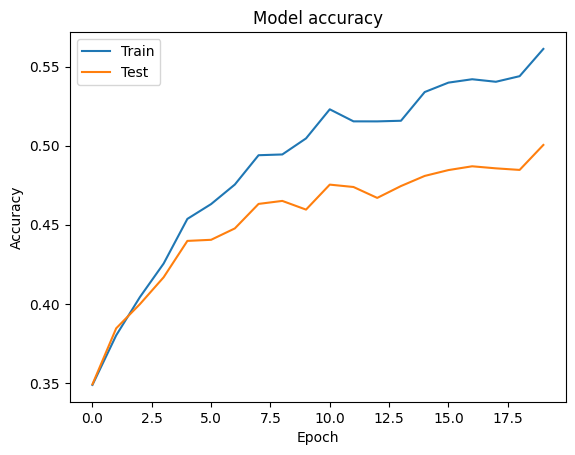

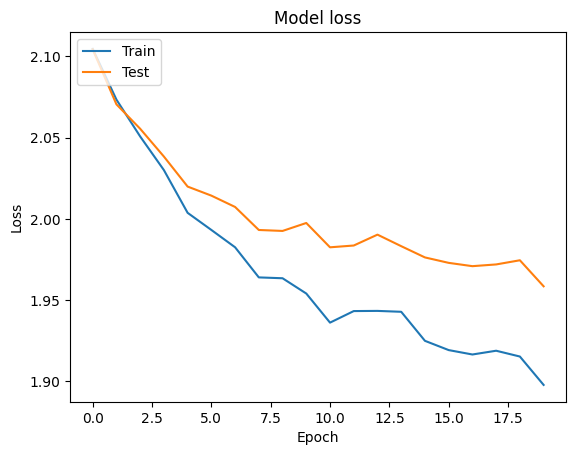

In [ ]:
plt.plot(train_acc)
plt.plot(test_acc)
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

plt.plot(train_losses)
plt.plot(test_losses)
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


### 1-7　混合行列の表示

In [ ]:
def pred_class(loader_list):
    pred_classes = []
    for (x, _) in tqdm.tqdm(loader_list, "evaluating... ", position=0, leave=True):
        x = torch.reshape(x, (-1, 3 * 32 * 32)) # channel lastをchannel firstに変更している
        x = x.to(device)
        pred = model(x)
        pred_classes += torch.argmax(pred, dim=1).cpu().detach().numpy().tolist()

    return pred_classes


evaluating... : 100%|██████████| 5/5 [00:00<00:00, 70.78it/s]


true label    =  [3, 8, 8, 0, 6, 6, 1, 6, 3, 1, 0, 9, 5, 7, 9, 8, 5, 7, 8, 6, 7, 0, 4, 9, 5, 2, 4, 0, 9, 6, 6, 5, 4, 5, 9, 2, 4, 1, 9, 5, 4, 6, 5, 6, 0, 9, 3, 9, 7, 6, 9, 8, 0, 3, 8, 8, 7, 7, 4, 6, 7, 3, 6, 3, 6, 2, 1, 2, 3, 7, 2, 6, 8, 8, 0, 2, 9, 3, 3, 8, 8, 1, 1, 7, 2, 5, 2, 7, 8, 9, 0, 3, 8, 6, 4, 6, 6, 0, 0, 7]
predict label =  [3, 8, 8, 8, 4, 6, 3, 6, 3, 1, 8, 9, 1, 7, 9, 8, 5, 9, 8, 6, 4, 0, 0, 9, 4, 6, 4, 2, 9, 6, 6, 4, 4, 5, 9, 1, 6, 9, 9, 5, 0, 4, 3, 4, 0, 9, 3, 9, 4, 4, 9, 8, 6, 4, 8, 8, 5, 6, 3, 5, 7, 3, 1, 9, 3, 2, 1, 8, 5, 9, 2, 4, 8, 8, 0, 4, 9, 3, 6, 0, 8, 1, 1, 3, 2, 9, 2, 8, 8, 9, 0, 4, 8, 6, 4, 5, 4, 0, 2, 9]


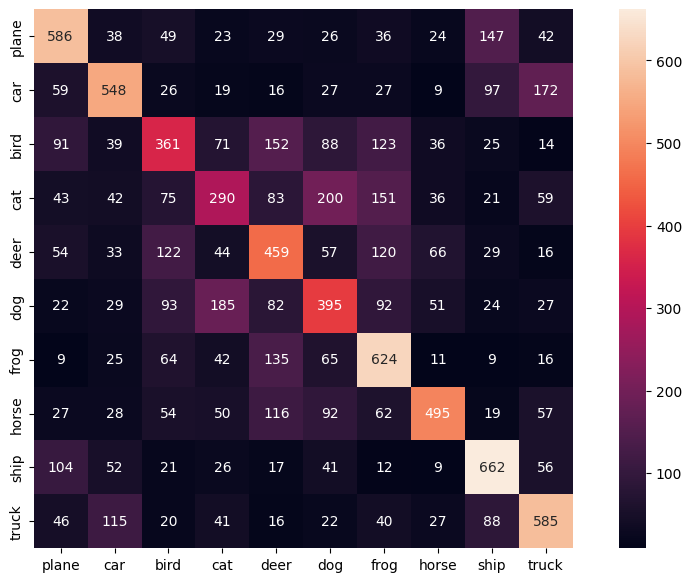

In [ ]:
# 混合行列の表示
predict_classes = pred_class(list(test_loader))
print('true label    = ', test_dataset.targets[:100])
print('predict label = ', predict_classes[:100])
cmx_data = confusion_matrix(test_dataset.targets, predict_classes)
df_cmx = pd.DataFrame(cmx_data)
plt.figure(figsize=(12, 7))
sn.heatmap(df_cmx, annot=True, fmt='g', square=True, yticklabels=classes, xticklabels=classes)
plt.show()


### 混合行列の見方

-  左側のラベル：画像のラベル（True）
-  下のラベル：予測のラベル（Predict）

例：

- 0行0列目　planeの画像のうちplaneと予測したものは519枚
- 0行1列目　planeの画像のうちcarと予測したものは70枚
- 1行0列目　carの画像のうちplaneと予測したものは46枚


この結果を踏まえて問7を回答してください．

# 以降は第１２回の内容（頭出しは授業zoomで行う予定です）

# 課題２．画像を2次元の状態で学習

### 2-1 画像が二次元か確認

In [ ]:
print("image_data  = ", train_dataset.data[0])
print("image_shape = ", train_dataset.data[0].shape)

image_data  =  [[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]
image_shape =  (32, 32, 3)


### 2-2 二次元用のモデルを設定

In [ ]:
input_shape = IMAGE_SIZE
output_shape = NUM_CLASS


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)  # 入力のチャネル、出力のチャネル（＝フィルター数）、フィルタのサイズ（3 * 3）
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1) #
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.fc1 = nn.Linear(2048, 256)
        self.fc2 = nn.Linear(256, 10)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))

        x = self.fc2(x)
        x = self.softmax(x)
        return x


model = Net()
model.to(device)

criterion = nn.CrossEntropyLoss()
# optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
optimizer = torch.optim.Adam(model.parameters())
summary(model, (3, 32, 32))

print('入力のサイズ:', input_shape)
print('出力のサイズ:', output_shape)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
              ReLU-2           [-1, 32, 32, 32]               0
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
              ReLU-5           [-1, 64, 16, 16]               0
         MaxPool2d-6             [-1, 64, 8, 8]               0
            Conv2d-7            [-1, 128, 8, 8]          73,856
              ReLU-8            [-1, 128, 8, 8]               0
         MaxPool2d-9            [-1, 128, 4, 4]               0
           Linear-10                  [-1, 256]         524,544
             ReLU-11                  [-1, 256]               0
           Linear-12                   [-1, 10]           2,570
          Softmax-13                   [-1, 10]               0
Total params: 620,362
Trainable params:

上記が，課題2におけるモデルの構造です．

では，ワークシートの問8,9,10を回答してください．


### 2-3 モデルの学習

In [ ]:
def calc_loss_and_accuracy(loader_list):
    acc = 0
    cnt = 0
    loss = 0
    for (x, y) in tqdm.tqdm(loader_list, "evaluating... ", position=0, leave=True):
        x = x.to(device)
        y = y.to(device)
        x = torch.reshape(x, (-1, 3, 32, 32))
        pred = model(x)
        loss += criterion(pred, y).item()
        pred = torch.argmax(pred, dim=1)
        for o, t in zip(pred, y):
            if o == t:
                acc += 1
            cnt += 1
    return loss / len(loader_list), acc / cnt

In [ ]:
def train(epochs):
    train_losses, train_accs, test_losses, test_accs = [], [], [], []
    train_loader_list = list(train_loader)
    test_loader_list = list(test_loader)
    for epoch in range(epochs):
        for (x, y) in tqdm.tqdm(train_loader_list, f"[{epoch + 1}/{epochs}] training... ", position=0, leave=True):
            x = torch.reshape(x, (-1, 3, 32, 32))
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()

        train_loss, train_acc = calc_loss_and_accuracy(train_loader_list)
        test_loss, test_acc = calc_loss_and_accuracy(test_loader_list)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        print(
            f'\n[*] train_Loss = {train_loss} | train_Accuracy = {train_acc} | test_Loss = {test_loss}| test_Accuracy = {test_acc}')
    return train_losses, train_accs, test_losses, test_accs


st = time.time()
train_losses, train_accs, test_losses, test_accs = train(EPOCHS)
elapsed_time = time.time() - st


evaluating... : 100%|██████████| 5/5 [00:00<00:00, 14.41it/s]



[*] train_Loss = 2.135210657119751 | train_Accuracy = 0.31458 | test_Loss = 2.131162643432617| test_Accuracy = 0.3178


evaluating... : 100%|██████████| 5/5 [00:00<00:00, 14.09it/s]



[*] train_Loss = 2.063977098464966 | train_Accuracy = 0.39272 | test_Loss = 2.059267282485962| test_Accuracy = 0.3972


evaluating... : 100%|██████████| 5/5 [00:00<00:00, 13.95it/s]


...


[*] train_Loss = 1.812892370223999 | train_Accuracy = 0.65412 | test_Loss = 1.8409141302108765| test_Accuracy = 0.6193


evaluating... : 100%|██████████| 5/5 [00:00<00:00, 14.13it/s]



[*] train_Loss = 1.7990104961395263 | train_Accuracy = 0.6673 | test_Loss = 1.833002257347107| test_Accuracy = 0.6306


evaluating... : 100%|██████████| 5/5 [00:00<00:00, 14.26it/s]


[*] train_Loss = 1.7831175851821899 | train_Accuracy = 0.68552 | test_Loss = 1.8222906112670898| test_Accuracy = 0.639


### 2-4　学習結果の確認

In [ ]:
print('Train loss:', train_losses[len(train_losses) - 1])
print('Test loss:', test_losses[len(test_losses) - 1])

print('Train accuracy:', train_accs[len(train_accs) - 1])
print('Test accuracy:', test_accs[len(test_accs) - 1])

print('実行時間(秒) : ', elapsed_time)

Train loss: 1.7831175851821899
Test loss: 1.8222906112670898
Train accuracy: 0.68552
Test accuracy: 0.639
実行時間(秒) :  97.32330226898193


上記が，このモデルの学習結果です．

では，問11を回答してください．

### 2-5　学習過程をグラフで表示


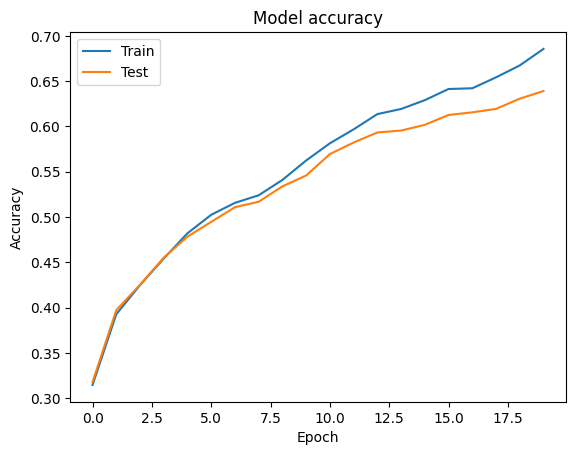

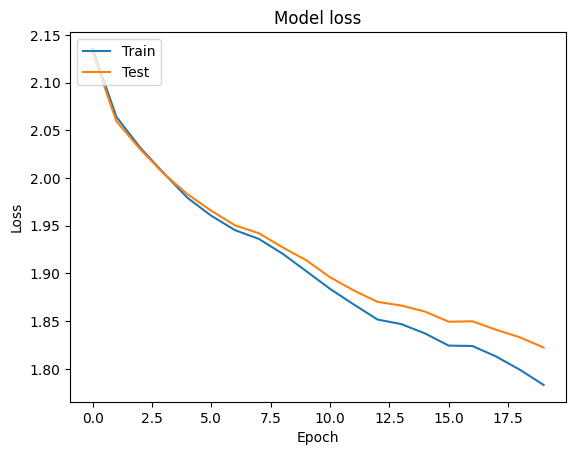

In [ ]:
plt.plot(train_accs)
plt.plot(test_accs)
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

plt.plot(train_losses)
plt.plot(test_losses)
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

### 2-6　混合行列の表示


In [ ]:
def pred_class(loader_list):
    pred_classes = []
    for (x, _) in tqdm.tqdm(loader_list, "evalueating... ", position=0, leave=True):
        x = torch.reshape(x, (-1, 3 , 32 , 32))
        x = x.to(device)
        pred = model(x)
        pred_classes += torch.argmax(pred, dim=1).cpu().detach().numpy().tolist()

    return pred_classes

evalueating... : 100%|██████████| 5/5 [00:00<00:00, 32.45it/s]


true label    =  [3, 8, 8, 0, 6, 6, 1, 6, 3, 1, 0, 9, 5, 7, 9, 8, 5, 7, 8, 6, 7, 0, 4, 9, 5, 2, 4, 0, 9, 6, 6, 5, 4, 5, 9, 2, 4, 1, 9, 5, 4, 6, 5, 6, 0, 9, 3, 9, 7, 6, 9, 8, 0, 3, 8, 8, 7, 7, 4, 6, 7, 3, 6, 3, 6, 2, 1, 2, 3, 7, 2, 6, 8, 8, 0, 2, 9, 3, 3, 8, 8, 1, 1, 7, 2, 5, 2, 7, 8, 9, 0, 3, 8, 6, 4, 6, 6, 0, 0, 7]
predict label =  [3, 1, 8, 8, 6, 6, 1, 4, 3, 1, 0, 9, 5, 7, 9, 8, 5, 7, 8, 6, 7, 2, 0, 9, 4, 6, 4, 4, 9, 6, 6, 4, 4, 3, 9, 3, 4, 9, 9, 5, 8, 6, 5, 6, 0, 9, 3, 3, 4, 6, 9, 8, 6, 3, 8, 8, 7, 8, 5, 3, 7, 5, 4, 1, 6, 2, 1, 0, 3, 7, 2, 6, 8, 8, 0, 2, 9, 3, 5, 8, 8, 1, 1, 5, 2, 7, 2, 8, 8, 9, 0, 4, 8, 6, 4, 6, 6, 2, 0, 7]


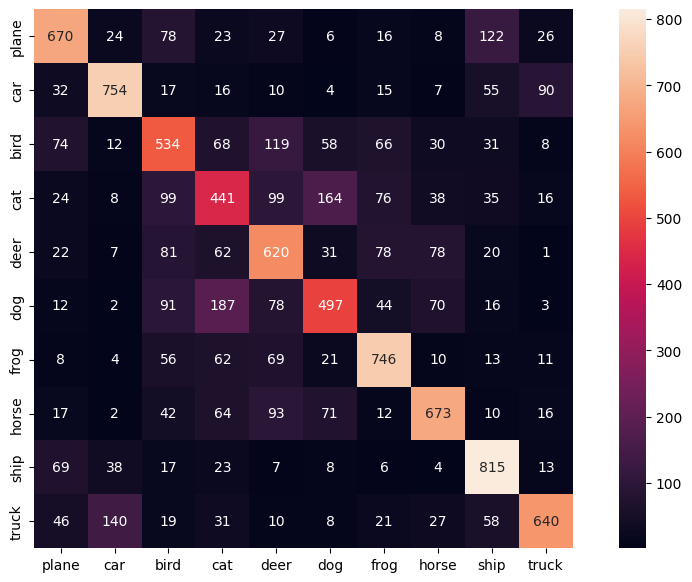

In [ ]:

# 混同行列の表示
predict_classes = pred_class(list(test_loader))
print('true label    = ', test_dataset.targets[:100])
print('predict label = ', predict_classes[:100])
cmx_data = confusion_matrix(test_dataset.targets, predict_classes)
df_cmx = pd.DataFrame(cmx_data)
plt.figure(figsize=(12, 7))
sn.heatmap(df_cmx, annot=True, fmt='g', square=True, yticklabels=classes, xticklabels=classes)
plt.show()

以上の結果を踏まえて問12,13を回答してください．

# END.

In [ ]:
# 最終課題追加部分 Vision Transformer

ViT Train Data : 50000
ViT Test Data  : 10000
画像サイズ
torch.Size([64, 3, 224, 224])
ラベル
tensor([9, 9, 4, 1, 5, 0, 3, 8, 2, 4])


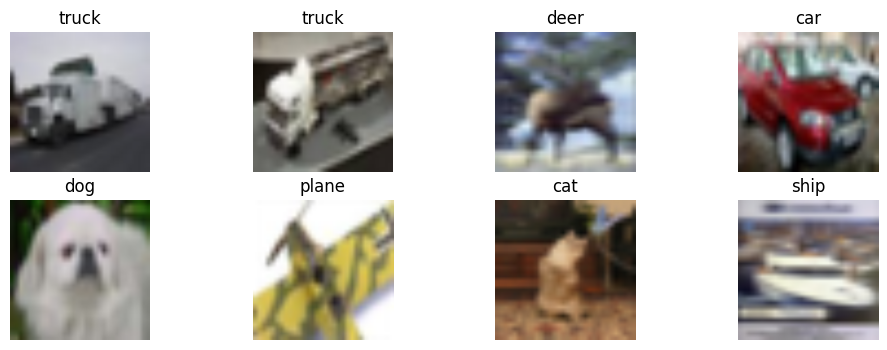

In [ ]:
############################################################
# Vision Transformerによる画像分類
############################################################

# timmがインストールされていない場合だけ実行
# timmにはVision Transformerなど多くの画像認識モデルが用意されている
!pip -q install timm

import timm
import copy
import numpy as np
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

############################################################
# ViT用データセット
############################################################

# Vision Transformerは224×224画像を入力する
vit_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# 学習用データセットを読み込む
vit_train_dataset = CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=vit_transform
)

# テスト用データセットを読み込む
vit_test_dataset = CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=vit_transform
)

# 学習用DataLoaderを作成
vit_train_loader = DataLoader(
    vit_train_dataset,
    batch_size=64,
    shuffle=True
)

# テスト用DataLoaderを作成
vit_test_loader = DataLoader(
    vit_test_dataset,
    batch_size=64,
    shuffle=False
)

print("ViT Train Data :", len(vit_train_dataset))
print("ViT Test Data  :", len(vit_test_dataset))

############################################################
# 動作確認
############################################################

images, labels = next(iter(vit_train_loader))

print("画像サイズ")
print(images.shape)

print("ラベル")
print(labels[:10])

# サンプル画像表示
plt.figure(figsize=(12,4))

for i in range(8):
    plt.subplot(2,4,i+1)

    img = images[i].permute(1,2,0).numpy()

    img = img * 0.5 + 0.5
    img = np.clip(img,0,1)

    plt.imshow(img)
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.show()

In [ ]:
############################################################
# 3-2 Vision Transformerモデルの設定
############################################################

# # timmライブラリからVision Transformerモデルを作成する
# 使用するモデル名
# vit：Vision Transformer
# tiny：小型モデル（計算量が少ない）
# patch16：画像を16×16ピクセルごとのパッチに分割して処理する
# 224：入力画像サイズ224×224を前提としている
model_vit = timm.create_model(
    "vit_tiny_patch16_224",
    # ImageNetで事前学習された重みを利用する（転移学習）
    pretrained=True,
    num_classes=10
)

model_vit.to(device)

print(model_vit)

############################################################
# 損失関数・最適化手法
############################################################

criterion_vit = nn.CrossEntropyLoss()

# Adamを用いてモデルの重みを更新する
optimizer_vit = torch.optim.Adam(
    model_vit.parameters(),
    lr=0.0001
)

############################################################
# 学習率スケジューラ
############################################################

# 学習率を自動で変更する設定
#学習の前半には大きく重みを更新、後半は細かく調整するため
scheduler_vit = torch.optim.lr_scheduler.StepLR(
    # 対象となるOptimizer
    optimizer_vit,
    # 5エポックごとに学習率を変更する
    step_size=5,
    # 学習率を0.5倍にする
    gamma=0.5
)

############################################################
# パラメータ数
############################################################

# パラメータ数を計算する
total_params = sum(p.numel() for p in model_vit.parameters())
trainable_params = sum(
    p.numel()
    for p in model_vit.parameters()
    if p.requires_grad
)

print("="*50)
print("Vision Transformer")
print("="*50)
print(f"総パラメータ数 : {total_params:,}")
print(f"学習パラメータ数 : {trainable_params:,}")

############################################################
# GPU確認
############################################################

print("Device :", device)

############################################################
# 動作確認
############################################################

# ランダムな画像(224×224 RGB画像)を1枚作成する
dummy = torch.randn(1,3,224,224).to(device)

# 推論のみ行うため勾配計算を無効化する
with torch.no_grad():
    output = model_vit(dummy)

print("入力サイズ :", dummy.shape)
print("出力サイズ :", output.shape)

assert output.shape == (1,10)

print("Vision Transformerの準備完了")

model.safetensors: reconstructing file:   0%|          |  0.00B / 22.9MB            

model.safetensors: downloading bytes:           |  0.00B            

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


In [ ]:
############################################################
# 3-3 モデルの学習
############################################################

def calc_loss_and_accuracy_vit(loader):

    model_vit.eval()

    loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        # DataLoaderから画像を取り出す
        for images, labels in tqdm.tqdm(loader, "evaluating... ", leave=True):

            images = images.to(device)
            labels = labels.to(device)

            # 画像を入力して予測する
            outputs = model_vit(images)

            batch_loss = criterion_vit(outputs, labels)

            loss += batch_loss.item()

            # 最も確率が高いクラス番号を取得
            pred = torch.argmax(outputs, dim=1)

            correct += (pred == labels).sum().item()

            total += labels.size(0)

    return loss / len(loader), correct / total


############################################################

# ViTを学習する関数
def train_vit(epochs):

    train_losses = []
    test_losses = []

    train_accs = []
    test_accs = []

    best_acc = 0

    # 最良モデルを保存するためコピー
    best_model = copy.deepcopy(model_vit.state_dict())

    for epoch in range(epochs):

        print("="*60)
        print(f"Epoch {epoch+1}/{epochs}")
        print("="*60)

        model_vit.train()

        running_loss = 0

        # 学習データを1バッチずつ取り出す
        for images, labels in tqdm.tqdm(vit_train_loader,
                                        "training... ",
                                        leave=True):

            images = images.to(device)
            labels = labels.to(device)

            optimizer_vit.zero_grad()

            outputs = model_vit(images)

            loss = criterion_vit(outputs, labels)

            loss.backward()

             # 重み更新
            optimizer_vit.step()

            running_loss += loss.item()

        scheduler_vit.step()
        # 学習データ・テストデータで評価
        train_loss, train_acc = calc_loss_and_accuracy_vit(vit_train_loader)
        test_loss, test_acc = calc_loss_and_accuracy_vit(vit_test_loader)


         # LossやAccuracyの保存
        train_losses.append(train_loss)
        test_losses.append(test_loss)

        train_accs.append(train_acc)
        test_accs.append(test_acc)

        print()
        print(f"Train Loss : {train_loss:.4f}")
        print(f"Train Acc  : {train_acc:.4f}")
        print(f"Test Loss  : {test_loss:.4f}")
        print(f"Test Acc   : {test_acc:.4f}")

        # 今までで最も高いAccuracyならモデルを保存
        if test_acc > best_acc:

            best_acc = test_acc

            best_model = copy.deepcopy(model_vit.state_dict())

            print("Best Model Updated")

        print()

    # 学習終了後、最も精度が高かったモデルへ戻す
    model_vit.load_state_dict(best_model)

    return train_losses, train_accs, test_losses, test_accs

In [ ]:
############################################################
# 3-4 学習の実行
############################################################

print("="*60)
print("Vision Transformer 学習開始")
print("="*60)

# 学習開始時刻を記録する
# 後で学習時間を計算するために使用
st = time.time()

# Vision Transformerの学習を開始する
# train_vit()からLossとAccuracyの推移を受け取る
train_losses_vit, train_accs_vit, test_losses_vit, test_accs_vit = train_vit(EPOCHS)

# 学習終了までにかかった時間を計算する
elapsed_time_vit = time.time() - st

print()
print("="*60)
print("学習終了")
print("="*60)

############################################################
# 学習結果
############################################################

print("Train Loss :", train_losses_vit[-1])
print("Test Loss  :", test_losses_vit[-1])

print()

print("Train Accuracy :", train_accs_vit[-1])
print("Test Accuracy  :", test_accs_vit[-1])

print()

print("実行時間(秒) :", elapsed_time_vit)

############################################################
# CNNとの比較用に保存
############################################################

cnn_result = {
    "accuracy": test_accs[-1],
    "loss": test_losses[-1],
    "time": elapsed_time
}

vit_result = {
    "accuracy": test_accs_vit[-1],
    "loss": test_losses_vit[-1],
    "time": elapsed_time_vit
}

############################################################
# 結果表示
############################################################

print()
print("="*60)
print("結果比較")
print("="*60)

print(f"CNN Accuracy : {cnn_result['accuracy']:.4f}")
print(f"ViT Accuracy : {vit_result['accuracy']:.4f}")

print()

print(f"CNN Loss : {cnn_result['loss']:.4f}")
print(f"ViT Loss : {vit_result['loss']:.4f}")

print()

print(f"CNN Time : {cnn_result['time']:.2f} sec")
print(f"ViT Time : {vit_result['time']:.2f} sec")

Vision Transformer 学習開始
Epoch 1/20


evaluating... : 100%|██████████| 157/157 [00:24<00:00,  6.39it/s]



Train Loss : 0.0937
Train Acc  : 0.9684
Test Loss  : 0.1621
Test Acc   : 0.9460
Best Model Updated

Epoch 2/20


evaluating... : 100%|██████████| 157/157 [00:24<00:00,  6.31it/s]



Train Loss : 0.0347
Train Acc  : 0.9897
Test Loss  : 0.1200
Test Acc   : 0.9601
Best Model Updated

Epoch 3/20


...


Train Loss : 0.0000
Train Acc  : 1.0000
Test Loss  : 0.1420
Test Acc   : 0.9730

Epoch 19/20


evaluating... : 100%|██████████| 157/157 [00:25<00:00,  6.26it/s]



Train Loss : 0.0000
Train Acc  : 1.0000
Test Loss  : 0.1458
Test Acc   : 0.9730

Epoch 20/20


evaluating... : 100%|██████████| 157/157 [00:24<00:00,  6.33it/s]


Train Loss : 0.0000
Train Acc  : 1.0000
Test Loss  : 0.1502
Test Acc   : 0.9729


学習終了
Train Loss : 4.786761464298424e-06
Test Loss  : 0.15015935895962973

Train Accuracy : 1.0
Test Accuracy  : 0.9729

実行時間(秒) : 8246.995612382889

結果比較
CNN Accuracy : 0.6390
ViT Accuracy : 0.9729

CNN Loss : 1.8223
ViT Loss : 0.1502

CNN Time : 97.32 sec
ViT Time : 8247.00 sec


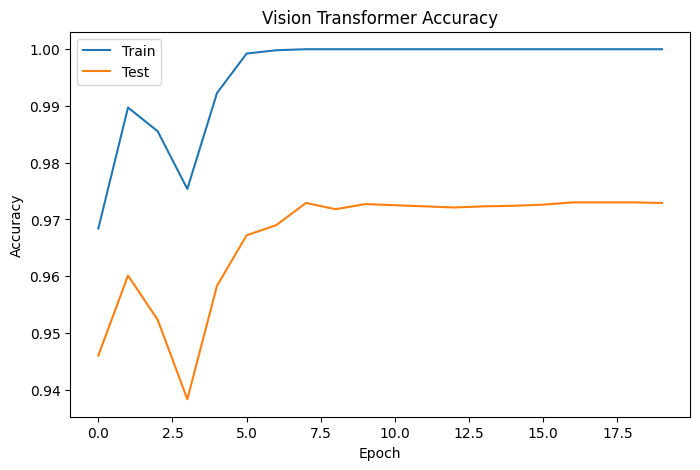

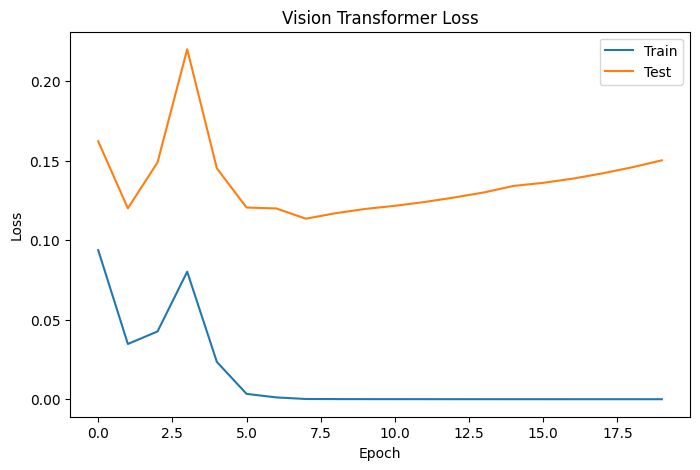

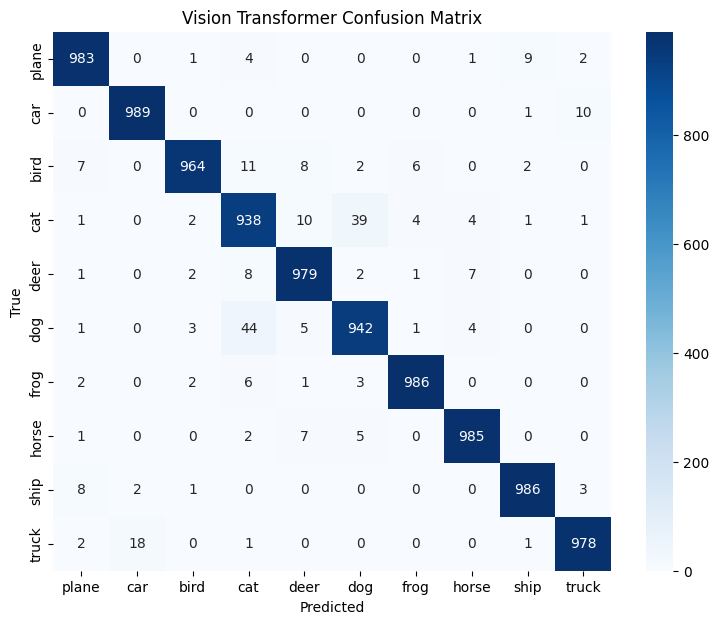

In [ ]:
############################################################
# 3-5 学習結果の可視化
############################################################

from sklearn.metrics import confusion_matrix
import seaborn as sns

############################################################
# Accuracy
############################################################

plt.figure(figsize=(8,5))

plt.plot(train_accs_vit, label="Train")
plt.plot(test_accs_vit, label="Test")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Vision Transformer Accuracy")
plt.legend()

plt.show()

############################################################
# Loss
############################################################

plt.figure(figsize=(8,5))

plt.plot(train_losses_vit, label="Train")
plt.plot(test_losses_vit, label="Test")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Vision Transformer Loss")
plt.legend()

plt.show()

############################################################
# Confusion Matrix
############################################################

model_vit.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for images, labels in vit_test_loader:

        images = images.to(device)

        outputs = model_vit(images)

        pred = torch.argmax(outputs,1)

        predictions.extend(pred.cpu().numpy())

        true_labels.extend(labels.numpy())

cm = confusion_matrix(true_labels,predictions)

plt.figure(figsize=(9,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Vision Transformer Confusion Matrix")

plt.show()

誤分類数 : 270


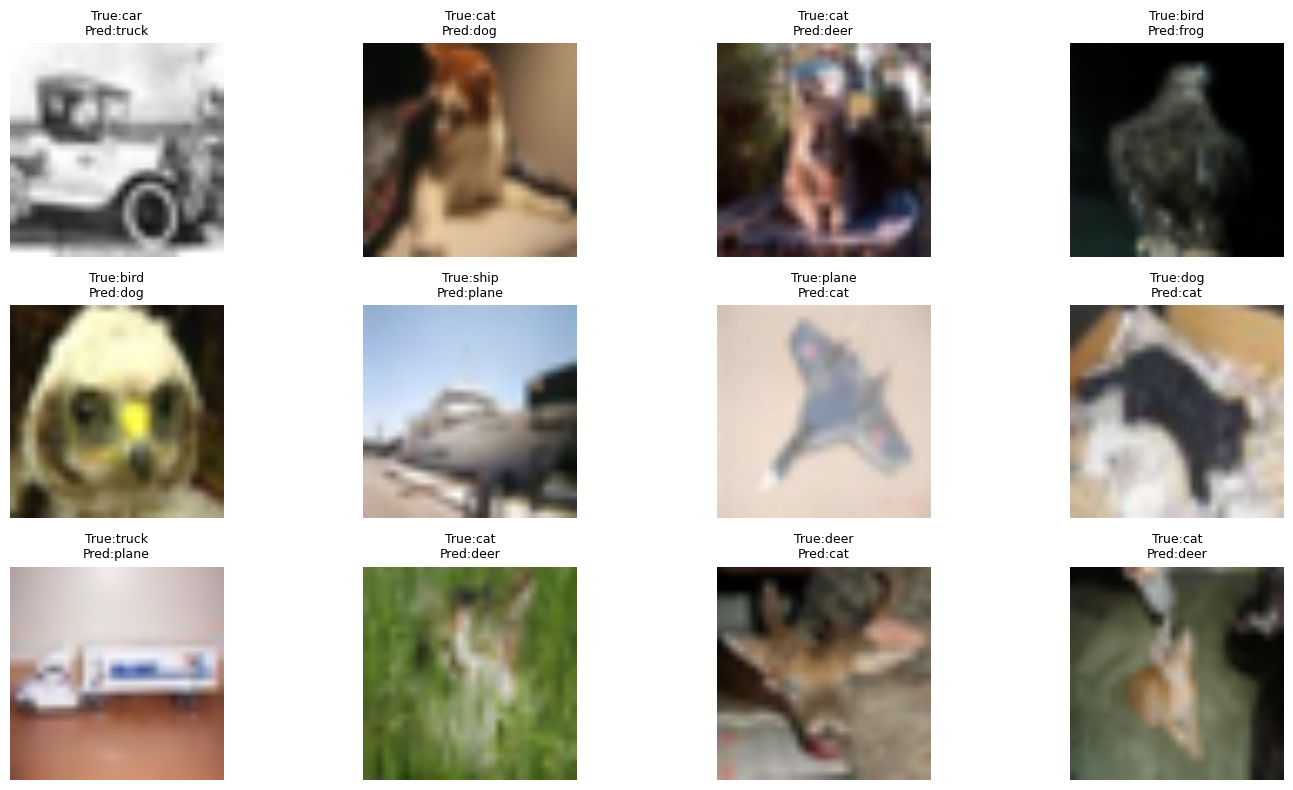

In [ ]:
############################################################
# 誤分類画像の表示
############################################################

model_vit.eval()

wrong_images = []
wrong_labels = []
wrong_preds = []

with torch.no_grad():

    for images, labels in vit_test_loader:

        outputs = model_vit(images.to(device))

        pred = torch.argmax(outputs,1).cpu()

        for i in range(len(labels)):

            if pred[i] != labels[i]:

                wrong_images.append(images[i])

                wrong_labels.append(labels[i])

                wrong_preds.append(pred[i])

print("誤分類数 :",len(wrong_images))

plt.figure(figsize=(15,8))

num_show = min(12,len(wrong_images))

for i in range(num_show):

    plt.subplot(3,4,i+1)

    img = wrong_images[i].permute(1,2,0).numpy()

    img = img*0.5+0.5
    img = np.clip(img,0,1)

    plt.imshow(img)

    plt.title(
        f"True:{classes[wrong_labels[i]]}\nPred:{classes[wrong_preds[i]]}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

                    項目        CNN  Vision Transformer
0        Test Accuracy   0.639000            0.972900
1            Test Loss   1.822291            0.150159
2  Training Time (sec)  97.323302         8246.995612


,項目,CNN,Vision Transformer
0,Test Accuracy,0.639000,0.972900
1,Test Loss,1.822291,0.150159
2,Training Time (sec),97.323302,8246.995612


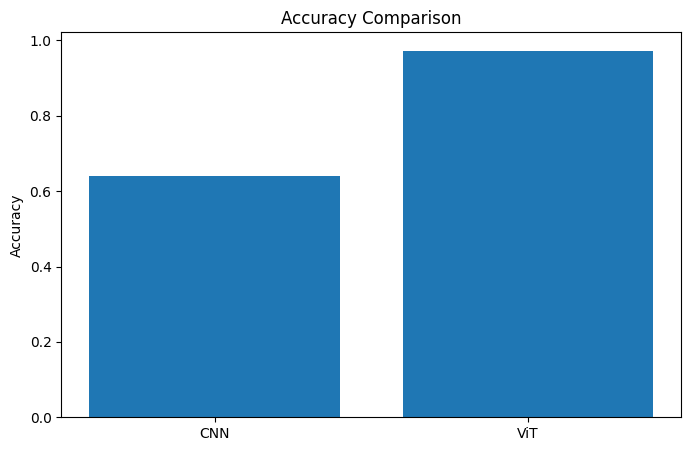

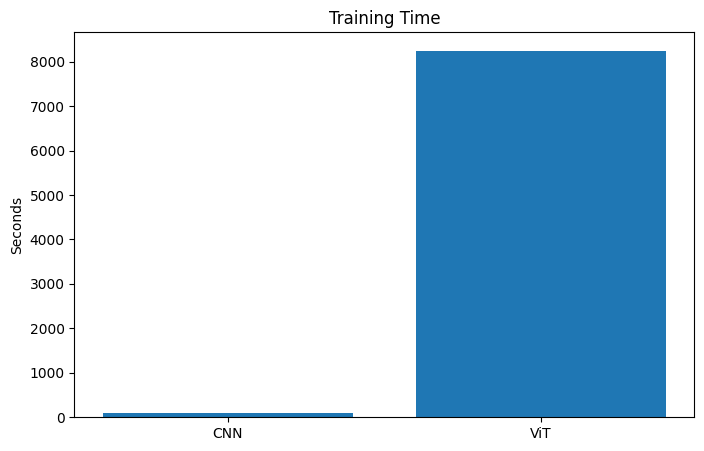

In [ ]:
############################################################
# 3-6 CNNとVision Transformerの比較
############################################################

import pandas as pd

comparison = pd.DataFrame({
    "項目":[
        "Test Accuracy",
        "Test Loss",
        "Training Time (sec)"
    ],
    "CNN":[
        cnn_result["accuracy"],
        cnn_result["loss"],
        cnn_result["time"]
    ],
    "Vision Transformer":[
        vit_result["accuracy"],
        vit_result["loss"],
        vit_result["time"]
    ]
})

print(comparison)

display(comparison)

############################################################
# 比較グラフ
############################################################

plt.figure(figsize=(8,5))

x = np.arange(2)

plt.bar(
    x,
    [cnn_result["accuracy"], vit_result["accuracy"]]
)

plt.xticks(
    x,
    ["CNN","ViT"]
)

plt.ylabel("Accuracy")

plt.title("Accuracy Comparison")

plt.show()


############################################################
# 学習時間比較
############################################################

plt.figure(figsize=(8,5))

plt.bar(
    ["CNN","ViT"],
    [cnn_result["time"], vit_result["time"]]
)

plt.ylabel("Seconds")

plt.title("Training Time")

plt.show()

In [ ]:
############################################################
# 考察
############################################################

print("="*60)
print("考察")
print("="*60)

if vit_result["accuracy"] > cnn_result["accuracy"]:

    print("Vision TransformerはCNNより高い分類精度となった。")

else:

    print("CNNの方が高い分類精度となった。")

print()

if vit_result["time"] > cnn_result["time"]:

    print("Vision Transformerは学習時間が長くなった。")

else:

    print("Vision Transformerの方が高速であった。")

print()

print("Vision Transformerは画像をパッチ単位に分割し、")
print("Transformerによって画像全体の関係を学習する。")

print()

print("CNNは局所特徴の抽出に優れている一方、")
print("Vision Transformerは広い範囲の特徴を学習できる。")

print()

print("そのため、高精度である反面、")
print("学習時間は長くなる傾向が確認できた。")

考察
Vision TransformerはCNNより高い分類精度となった。

Vision Transformerは学習時間が長くなった。

Vision Transformerは画像をパッチ単位に分割し、
Transformerによって画像全体の関係を学習する。

CNNは局所特徴の抽出に優れている一方、
Vision Transformerは広い範囲の特徴を学習できる。

そのため、高精度である反面、
学習時間は長くなる傾向が確認できた。
